In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [25]:
rfm=pd.read_csv("../data/processed/rfm.csv",index_col="CustomerID")
rfm.head()

,Recency,Frequency,Monetory,R_score,F_score,M_score,RFM_score,segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost customers
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Loyal_cusomter
12349.0,19,1,1757.55,3,1,4,314,Potenial Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost customers


In [26]:
rfm_features=rfm[['Recency','Frequency','Monetory']]

In [27]:
scaler=StandardScaler()#When you use StandardScaler, the transformed result is
#a NumPy array where each feature has been standardized to have mean = 0 and standard deviation = 1.

rfm_scaled=scaler.fit_transform(rfm_features)
rfm_scaled
import numpy as np

print("Means:", np.mean(rfm_scaled, axis=0))
print("Standard deviations:", np.std(rfm_scaled, axis=0))


Means: [2.70261760e-17 1.80174507e-17 1.80174507e-17]
Standard deviations: [1. 1. 1.]


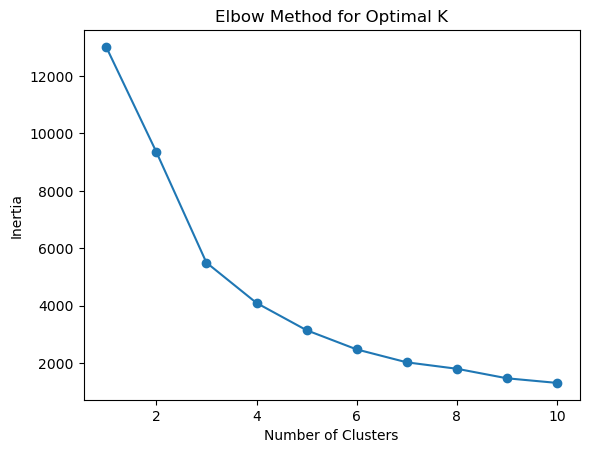

In [28]:
intertia=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(rfm_scaled)
    intertia.append(km.inertia_)
plt.plot(range(1,11),intertia,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

- The elbow curve shows diminishing returns after K = 3.
- This suggests that 3 clusters provide a good balance between compactness and simplicity.

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetory,R_score,F_score,M_score,RFM_score,segment,Cluster
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost customers,1
12347.0,2,7,4310.00,4,4,4,444,Champions,0
12348.0,75,4,1797.24,2,3,4,234,Loyal_cusomter,0
12349.0,19,1,1757.55,3,1,4,314,Potenial Loyalists,0
12350.0,310,1,334.40,1,1,2,112,Lost customers,1


In [30]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Recency', 'Frequency', 'Monetary']
)

cluster_centers

,Recency,Frequency,Monetary
0,40.983906,4.852677,2012.111620
1,246.023788,1.582800,631.141410
2,7.142857,80.214286,122888.407143


In [33]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetory', 'R_score', 'F_score', 'M_score',
       'RFM_score', 'segment', 'Cluster'],
      dtype='object')

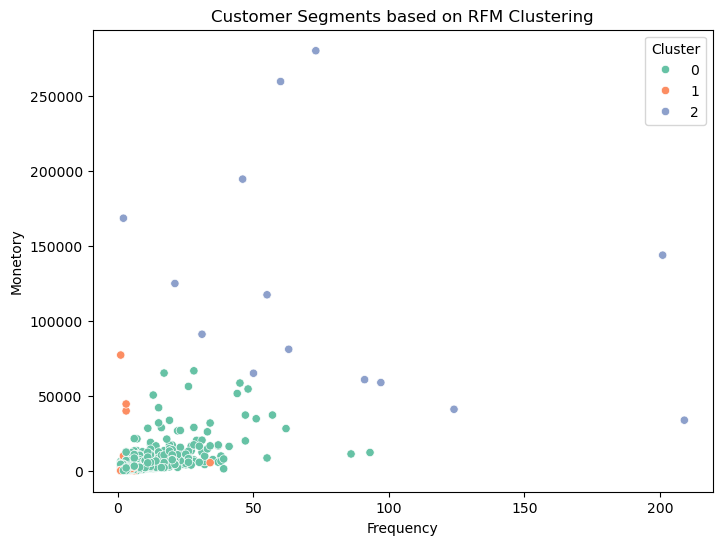

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetory',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segments based on RFM Clustering")
plt.show()

- Customers cluster naturally into three distinct behavioral groups.
- One cluster shows high frequency and high monetary value, indicating loyal and high-value customers.
- Another cluster shows low frequency and low spending, representing inactive or churn-risk customers.

In [36]:
pd.crosstab(rfm['Cluster'], rfm['segment'])

segment,At risk,Champions,Lost customers,Loyal_cusomter,Potenial Loyalists
Cluster,,,,,
0,204,1306,404,619,698
1,199,0,749,145,0
2,0,13,0,0,1


- KMeans clusters align strongly with rule-based RFM segments.
- This validates the RFM segmentation logic using a data-driven approach.
- Differences highlight customers with mixed behaviors not captured by simple rules.